In [2]:
import os
import sys

sys.path.insert(1, os.path.join(os.getcwd()  , 'Modules/'))

print(sys.path)

import pandas as pd
import numpy as np

import re
import logging
from Modules.Loader_wrangler import *
from Modules.Transformations import *
from Modules.ToTensor import *
from Modules.TravNet import *
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt

['/home/trapfishscott/miniconda3/envs/TravNet/lib/python312.zip', '/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/TravNet/Modules/', '/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/TravNet/Modules/', '/home/trapfishscott/miniconda3/envs/TravNet/lib/python3.12', '/home/trapfishscott/miniconda3/envs/TravNet/lib/python3.12/lib-dynload', '', '/home/trapfishscott/miniconda3/envs/TravNet/lib/python3.12/site-packages']
Training running on: cuda
Training running on: cuda


In [2]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')

In [3]:
# Absolute Paths

root_folder = os.getcwd()
data_folder = root_folder + "/data"
Models_folder = root_folder + "/Models"
tensors_folder = root_folder + "/tensors"
Results_folder = root_folder + "/Results"

# Loading, Reading & Transforming to Tensors

In [3]:
# Define data range

years_to_extract = list(range(2017,2018))


Unhash below if you want to load

In [ ]:
# df = loader(output_file_name="merged_df2017.pkl", chunksize=100000, sample_size=100000, survey_years=years_to_extract)

SurveyYear = ['2017'] not found in chunk 54. Continuing
Merged chunks saved to pickle!


In [ ]:
nts_df = pd.read_pickle(data_folder +"/merged_df2017.pkl")

### Exploring correlations with some of the target variables

In [23]:
ro_20_distance = return_correlated_columns(nts_df, ro=0.2, outcome_col="TripDisExSW")

Number of useful columns found: 8


In [24]:
# For TripPurpouse, default parameter for outcome col

ro_20_purpouse = return_correlated_columns(nts_df, ro=0.2)

Number of useful columns found: 21


In [25]:
useful_cols = set(ro_20_distance).union(set(ro_20_purpouse))

In [26]:
print("Some columns for distance/ purpouse: ")
for col in useful_cols:
    print(col)

Some columns for distance/ purpouse: 
DrivLic_B02ID
VehAnMileage
TripDisExSW
HHoldEmploy_B01ID
VehComMile_B01ID
EcoStat_B02ID
NumTrips
TripTotalTime
HHoldNumPeople
WkPlace_B01ID
TripDisIncSW
JourSeq
W5xHH
TripDisIncSW_B01ID
Age_B01ID
HHoldStruct_B02ID
JD
HRPWorkStat_B02ID
HHoldNumChildren
TripTravTime_B01ID
TripTotalTime_B01ID
EcoStat_B03ID
TripTravTime
EducN_B01ID


### Defining relevant variables

In [11]:
#TODO Make this somehow neater

#temporal_vars = ["TWSMonth", "TravelYear", "TravelWeekDay_B01ID"]
#individual_vars =["PSUGOR_B02ID", "IndIncome2002_B02ID", "HHoldNumChildren", "DVLALengthBand_B01ID"]

numerical_outcome_vars = ["TripStart", "TripEnd", "TripDisExSW"]
categorical_outcome_vars = ["TripPurpose_B01ID", "IsTrip"]

extra_vars = ["IndividualID_x", "JourSeq"]
features_one_hot = ["PSUGOR_B02ID"]

features_numerical = [  "DrivLic_B02ID",
                        "VehAnMileage",
                        "HHoldEmploy_B01ID",
                        "VehComMile_B01ID",
                        "EcoStat_B02ID",
                        "HHoldNumPeople",
                        "WkPlace_B01ID",
                        "Age_B01ID",
                        "HHoldStruct_B02ID",
                        "HRPWorkStat_B02ID",
                        "HHoldNumChildren",
                        "EcoStat_B03ID",
                        "EducN_B01ID",
                        "TravelYear"]


features_cyclical = ["TWSMonth", "TravelWeekDay_B01ID"]

features = features_one_hot + features_numerical + features_cyclical
outcomes = numerical_outcome_vars + categorical_outcome_vars

In [ ]:
ts_df = nts_df[features + outcomes + extra_vars]

# Apply cyclical encoding to cyclical column, assuming the same categories that appear in 2017 appear elsewhere

standard_mms.fit_transform(ts_df[features_numerical])
ohe.fit_transform(ts_df[features_one_hot])

# Careful not to run twice

for col in features_one_hot:
    ts_df.loc[:,col] = ts_df.loc[:,col].astype(int)

ts_df.loc[:, "TravelWeekDay_B01ID"] = ts_df.loc[:, "TravelWeekDay_B01ID"].astype(int)


### Showcase: At random selects an individuals and shows the transformation process and the final features w/ indices

In [38]:

target_cols = prepare_data_for_LSTM(long_df=ts_df, 
                                    features=features,
                                    outcomes=outcomes,
                                    categorical_outcome_vars=categorical_outcome_vars,
                                    features_numerical=features_numerical,
                                    features_cyclical=features_cyclical,
                                    features_one_hot=features_one_hot,
                                    extra_vars=extra_vars,
                                    cyclical_encoder=apply_cyclical_encoding,
                                    custom_numerical_scaler=custom_numerical_scaler,
                                    log_transformer=log_transformer,
                                    debug=True,
                                    max_journey_seq=10, 
                                    seq_length = 7)

0: TripStart_1
1: TripEnd_1
2: TripStart_2
3: TripEnd_2
4: TripStart_3
5: TripEnd_3
6: TripStart_4
7: TripEnd_4
8: TripStart_5
9: TripEnd_5
10: TripStart_6
11: TripEnd_6
12: TripStart_7
13: TripEnd_7
14: TripStart_8
15: TripEnd_8
16: TripStart_9
17: TripEnd_9
18: TripStart_10
19: TripEnd_10
20: TripDisExSW_1
21: TripDisExSW_2
22: TripDisExSW_3
23: TripDisExSW_4
24: TripDisExSW_5
25: TripDisExSW_6
26: TripDisExSW_7
27: TripDisExSW_8
28: TripDisExSW_9
29: TripDisExSW_10
30: TripPurpose_B01ID_1
31: TripPurpose_B01ID_2
32: TripPurpose_B01ID_3
33: TripPurpose_B01ID_4
34: TripPurpose_B01ID_5
35: TripPurpose_B01ID_6
36: TripPurpose_B01ID_7
37: TripPurpose_B01ID_8
38: TripPurpose_B01ID_9
39: TripPurpose_B01ID_10
40: IsTrip_1
41: IsTrip_2
42: IsTrip_3
43: IsTrip_4
44: IsTrip_5
45: IsTrip_6
46: IsTrip_7
47: IsTrip_8
48: IsTrip_9
49: IsTrip_10
50: DrivLic_B02ID
51: VehAnMileage
52: HHoldEmploy_B01ID
53: VehComMile_B01ID
54: EcoStat_B02ID
55: NumTrips
56: HHoldNumPeople
57: WkPlace_B01ID
58: Age_B

,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,PSUGOR_B02ID_0.0,PSUGOR_B02ID_1.0,PSUGOR_B02ID_2.0,PSUGOR_B02ID_3.0,PSUGOR_B02ID_4.0,PSUGOR_B02ID_5.0,PSUGOR_B02ID_6.0,PSUGOR_B02ID_7.0,PSUGOR_B02ID_8.0,PSUGOR_B02ID_9.0
0,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0,0,0.416667,0.427083,0.458333,0.468750,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.458333,0.472222,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,TripDisExSW_1,TripDisExSW_2,TripDisExSW_3,TripDisExSW_4,TripDisExSW_5,TripDisExSW_6,TripDisExSW_7,TripDisExSW_8,TripDisExSW_9,TripDisExSW_10
7,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,0
8,0.0,0.0,0,0,0.416667,0.427083,0.458333,0.468750,0.000000,0.000000,...,0.0,0,0.916291,0.916291,0.000000,0.000000,0,0.000000,0,0
9,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.458333,0.472222,...,0.0,0,0.000000,0.000000,0.405465,0.405465,0,0.000000,0,0
10,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,0
11,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,0
12,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0,0
13,0.0,0.0,0,0,0.513889,0.562500,0.572917,0.604167,0.718750,0.729167,...,0.0,0,3.295837,3.295837,1.609438,0.000000,0,1.609438,0,0


,TripPurpose_B01ID_1,TripPurpose_B01ID_2,TripPurpose_B01ID_3,TripPurpose_B01ID_4,TripPurpose_B01ID_5,TripPurpose_B01ID_6,TripPurpose_B01ID_7,TripPurpose_B01ID_8,TripPurpose_B01ID_9,TripPurpose_B01ID_10,IsTrip_1,IsTrip_2,IsTrip_3,IsTrip_4,IsTrip_5,IsTrip_6,IsTrip_7,IsTrip_8,IsTrip_9,IsTrip_10
7,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0
8,0.0,0,6.0,6.0,0.0,0.0,0,0.0,0,0,0.0,0,1.0,1.0,0.0,0.0,0,0.0,0,0
9,0.0,0,0.0,0.0,6.0,6.0,0,0.0,0,0,0.0,0,0.0,0.0,1.0,1.0,0,0.0,0,0
10,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0
11,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0
12,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0,0
13,0.0,0,22.0,22.0,16.0,0.0,0,16.0,0,0,0.0,0,1.0,1.0,1.0,0.0,0,1.0,0,0


### Creating Tensors for Neural Network

Tensors are already loaded, please unhash if you want to make them again.

In [63]:
'''

X, y_cont, y_cat = prepare_data_for_LSTM(long_df=ts_df, 
                                            features=features,
                                            outcomes=outcomes,
                                            categorical_outcome_vars=categorical_outcome_vars,
                                            features_numerical=features_numerical,
                                            features_cyclical=features_cyclical,
                                            features_one_hot=features_one_hot,
                                            extra_vars=extra_vars,
                                            cyclical_encoder=apply_cyclical_encoding,
                                            custom_numerical_scaler=custom_numerical_scaler,
                                            log_transformer=log_transformer,
                                            debug=False,
                                            transform_to_wide=True, 
                                            transform_to_tensor=True,
                                            max_journey_seq=10, 
                                            seq_length = 7)

# Save tensors #TODO BETTER FILE PATH
with open(tensors_folder + "/tensors.pkl", "wb") as f:
    pickle.dump((X, y_cont, y_cat), f)

'''

'\n\nX, y_cont, y_cat = prepare_data_for_LSTM(long_df=ts_df, \n                                            features=features,\n                                            outcomes=outcomes,\n                                            categorical_outcome_vars=categorical_outcome_vars,\n                                            features_numerical=features_numerical,\n                                            features_cyclical=features_cyclical,\n                                            features_one_hot=features_one_hot,\n                                            extra_vars=extra_vars,\n                                            cyclical_encoder=apply_cyclical_encoding,\n                                            custom_numerical_scaler=custom_numerical_scaler,\n                                            log_transformer=log_transformer,\n                                            debug=False,\n                                            transform_to_wide=True, \n            

### Importing Generated Data

### Results

In [30]:
results = pd.read_pickle(Results_folder + "/Results_10000.pkl")

In [64]:
results.head()

,i_id,DoW,TripNum,TripStart,Duration,Distance,Purpouse,IsTrip
0,0,0,1,625.045166,36.052731,3.560889,1.0,1.0
23,0,2,4,988.425598,26.895298,3.121760,5.0,1.0
30,0,3,1,625.036377,36.050648,3.561086,1.0,1.0
31,0,3,2,823.250000,40.241425,3.700542,1.0,1.0
32,0,3,3,953.710693,28.262978,3.194089,10.0,1.0


In [71]:
def get_agg_stats(data_real, data_gen):

    data_gen = data_gen.drop(["i_id", "IsTrip"], axis=1)
    data_gen["DoW"]+=1

    data_gen = data_gen.drop("Purpouse", axis=1)
    data_real = data_real.drop("TripPurpose_B01ID", axis=1)
    
    gen_stats = data_gen.agg(["mean", "median", "std"]).round(2)

    data_real = data_real.copy()
    data_real["Duration"] = data_real["TripEnd"] - data_real["TripStart"]

    data_real = data_real.rename(columns={"TripDisExSW": "Distance",
                                           "TripStart": "TripStart",
                                            "Duration": "Duration",
                                            "JourSeq": "TripNum",
                                            "TravelWeekDay_B01ID": "DoW"})
    
    data_real = data_real[data_gen.columns]


    real_stats  = data_real.agg(["mean", "median", "std"]).round(2)

    return gen_stats, real_stats

In [72]:
gen_stats, real_stats = get_agg_stats(ts_df, results)

print("Overall Aggregate stats")
print("Generated")
print(gen_stats)
print("Real")
print(real_stats)
print("")

for p in results["Purpouse"].unique():
    gen_stats, real_stats = get_agg_stats(ts_df[ts_df["TripPurpose_B01ID"]==p], results[results["Purpouse"]==p])
    print(f"Aggregate stats for purpouse=={p}")
    print("Generated")
    print(gen_stats)
    print("Real")
    print(real_stats)
    print("")

Overall Aggregate stats
Generated
        DoW  TripNum  TripStart  Duration  Distance
mean    4.0     2.55     815.47     27.03      3.99
median  4.0     2.00     844.76     25.66      4.09
std     2.0     1.66     166.58      8.58      0.64
Real
         DoW  TripNum  TripStart  Duration  Distance
mean    3.81     2.62     804.46     19.58      8.40
median  4.00     2.00     810.00     15.00      4.00
std     1.90     1.74     253.93     57.60     16.39

Aggregate stats for purpouse==1.0
Generated
        DoW  TripNum  TripStart  Duration  Distance
mean    4.0     1.48     713.32     27.60      4.39
median  4.0     1.00     630.89     27.27      4.43
std     2.0     0.50     123.32      6.09      0.39
Real
         DoW  TripNum  TripStart  Duration  Distance
mean    3.29     1.82     742.97     23.55     10.56
median  3.00     2.00     755.00     20.00      7.00
std     1.65     1.14     306.65     71.24     12.55

Aggregate stats for purpouse==5.0
Generated
        DoW  TripNum  Trip

**First Lets look at the distribution of trip types for the generated data**

In [69]:
results["Purpouse"].value_counts(normalize=True)

Purpouse
1.0     0.613234
5.0     0.172360
10.0    0.148447
23.0    0.065959
Name: proportion, dtype: float64

**And now for the real data**

In [7]:
ts_df["TripPurpose_B01ID"].value_counts(normalize=True).sort_index()

TripPurpose_B01ID
1.0     0.202108
2.0     0.048272
3.0     0.017113
4.0     0.003826
5.0     0.105764
6.0     0.096384
7.0     0.021578
8.0     0.000420
9.0     0.063616
10.0    0.095395
11.0    0.025884
12.0    0.011049
13.0    0.062537
14.0    0.014915
15.0    0.008771
16.0    0.039391
18.0    0.000829
19.0    0.020170
20.0    0.002488
21.0    0.066653
22.0    0.029321
23.0    0.063516
Name: proportion, dtype: float64

We can see that our model gets type=23 accurately. 10 is also quite accurate. It overshoots 1 substantially and 5 somewhat. It fails to predict the much rarer categories.

**Next we will look at the distribution of other target features for the purpouses it did pick up on**

In [54]:

def create_histograms(data_real, data_gen, variable_real, variable_gen, purpouse, percentile=None):

    data_real = data_real.copy()

    data_real["Duration"] = data_real["TripEnd"] - data_real["TripStart"]
    data_gen = data_gen.copy()

    data_real = data_real[data_real[variable_real] >= 0]
    data_gen = data_gen[data_gen[variable_gen] >= 0]

    # filtering for purpouse
    data_real = data_real[data_real["TripPurpose_B01ID"]==purpouse]
    data_gen = data_gen[data_gen["Purpouse"]==purpouse]

    if percentile is not None:
        p = data_real[variable_real].quantile(percentile)

        data_real = data_real[data_real[variable_real]<=p]
        data_gen = data_gen[data_gen[variable_gen]<=p]

    plt.hist(data_real[variable_real], alpha=0.2, bins= 10, label="Real data")
    plt.hist(data_gen[variable_gen], bins= 10, alpha=0.7, label="Generated data")

    plt.grid()
    plt.legend()
    

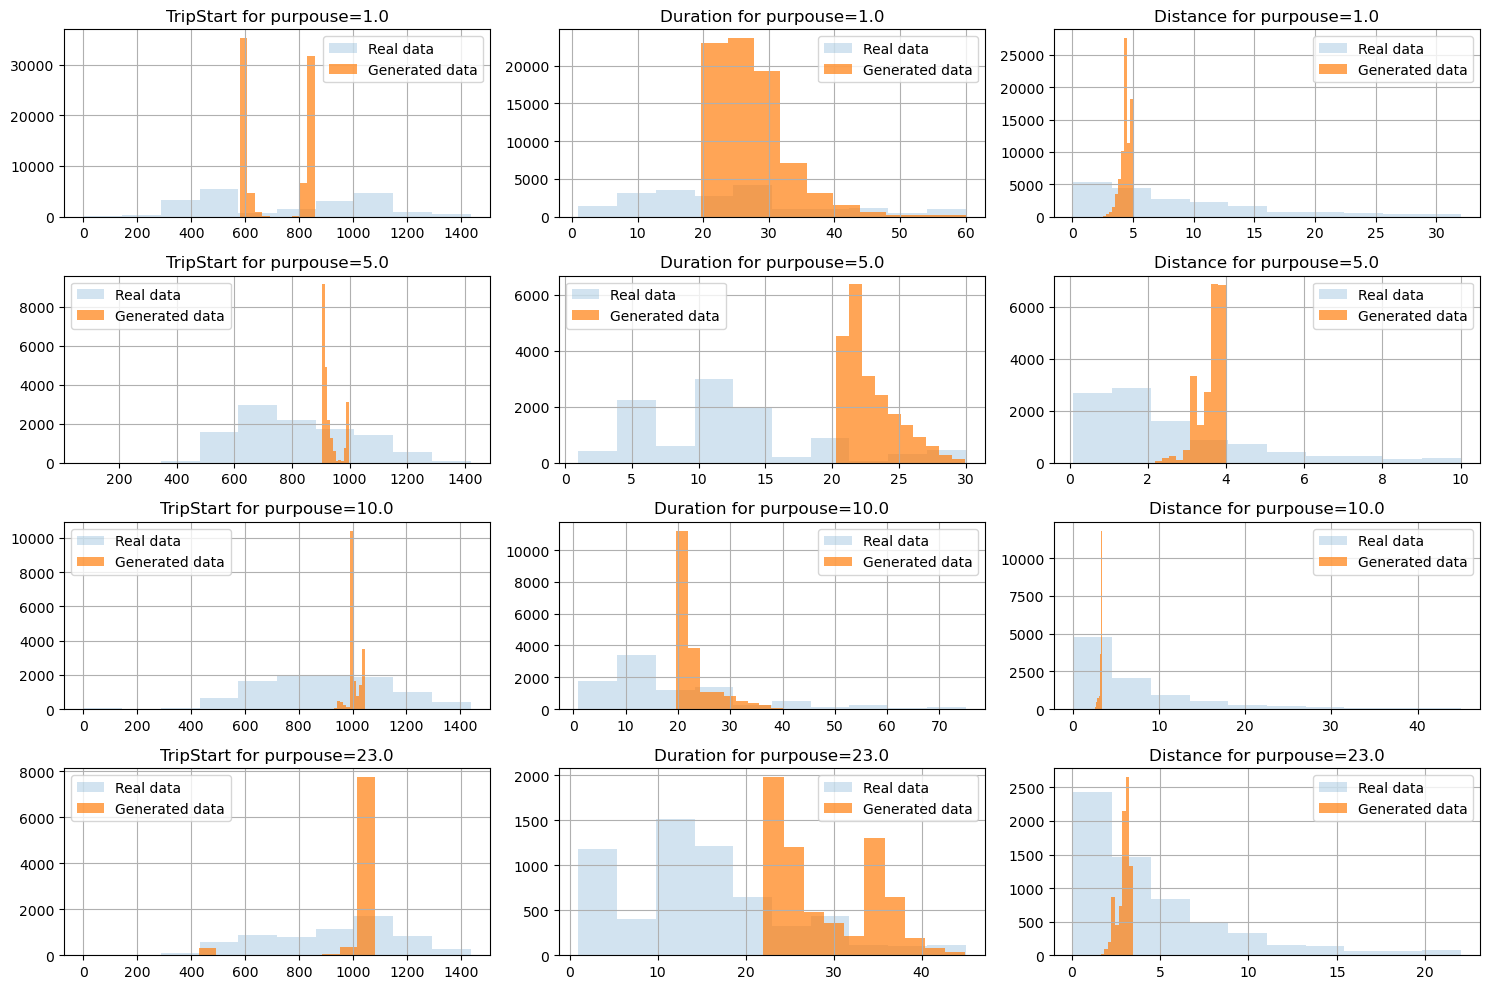

In [55]:
rows = len(results["Purpouse"].unique())
plt.figure(figsize=(15,10))

for i,p in enumerate(results["Purpouse"].unique()):

    plt.subplot(rows,3,1 + 3*i)

    plt.title(f"TripStart for purpouse={p}")

    create_histograms(data_real=ts_df, data_gen=results, variable_real="TripStart", variable_gen="TripStart", purpouse=p)

    plt.tight_layout()

    plt.subplot(rows,3,2 + 3*i)

    plt.title(f"Duration for purpouse={p}")

    create_histograms(data_real=ts_df, data_gen=results, variable_real="Duration", variable_gen="Duration", purpouse=p, percentile=0.95)

    plt.tight_layout()

    plt.subplot(rows,3,3 + 3*i)

    plt.title(f"Distance for purpouse={p}")

    create_histograms(data_real=ts_df, data_gen=results, variable_real="TripDisExSW", variable_gen="Distance", purpouse=p, percentile=0.95)

    plt.tight_layout()
    


